In [140]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import scipy.io
import torcwa
from tqdm.notebook import tqdm
from pvlib import spectrum
from refractiveindex import RefractiveIndexMaterial
%load_ext line_profiler

def get_sine_eps(x,params,grating_period,eps):
    """Generate sine grating permittivity profile.

    Args:
        x (torch.tensor): 1D tensor of x positions.
        params (torch.Tensor): list of amplitude and phase shift. shape (n,2), where n is n*2*np.pi/grating_period'th frequency.
        eps (float): Permittivity of high-index material.

    Returns:
        torch.tensor: 1D tensor of permittivity profile.
    """
    A = torch.sum(params[:,0])
    cosines = torch.cos(2.*np.pi*torch.arange(1, params.shape[0]+1, dtype=geo_dtype,device=device).unsqueeze(1)*(x.unsqueeze(0)/grating_period) + params[:,1].unsqueeze(1))
    cosines = cosines * params[:,0].unsqueeze(1)
    eps = 1 + (eps-1)*(0.5*(A+torch.sum(cosines, dim=0))/A)
    return eps.unsqueeze(1)   # make shape (nx,1) so add_layer accepts it

# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')

# Simulation environment
# light
inc_ang = 0.*(np.pi/180)    # radian
azi_ang = 0.*(np.pi/180)    # radian
spectra = spectrum.get_reference_spectra()
am15g = spectra['global']
wavelengths = torch.arange(350,1110,10,dtype=geo_dtype,device=device)  # nm
sun_weights = torch.tensor(am15g[wavelengths.cpu().numpy()].to_numpy())

# material
si = RefractiveIndexMaterial('main', book='Si', page='Green-2008')
si_eps = torch.tensor(si.get_refractive_index(wavelengths.cpu().numpy()) +
                      1j * si.get_extinction_coefficient(wavelengths.cpu().numpy()))**2

# geometry
h = 1000 #nm
grating_period = 500 # nm
L = [grating_period, 1.]  # Å
torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 300
torcwa.rcwa_geo.ny = 1
torcwa.rcwa_geo.grid()
z = torch.linspace(-h,1.5*h,501,device=device)

x_axis = torcwa.rcwa_geo.x.cpu()
y_axis = torcwa.rcwa_geo.y.cpu()
z_axis = z.cpu()

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [141]:
test = get_sine_eps(torcwa.rcwa_geo.x, torch.tensor([[0.5,0],[0.0,0],[0.0,0]], dtype=geo_dtype,device=device), grating_period, si_eps[0])

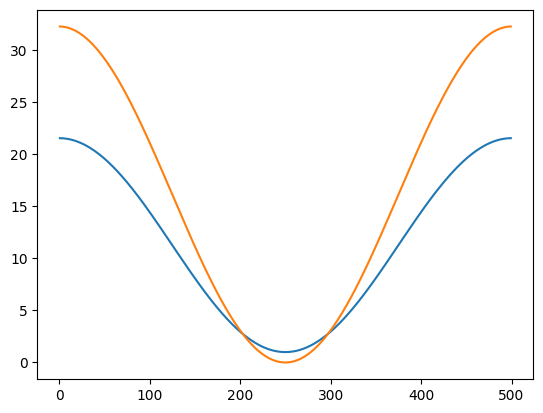

In [142]:
plt.plot(x_axis,torch.real(test).cpu())
plt.plot(x_axis,torch.imag(test).cpu())

In [228]:
def objective_function(params):
    order_N = 15
    order = [order_N,0]
    Absorptance = torch.zeros((2,61,1))
    A = torch.sum(params[:,0])
    z_film = torch.linspace(A,h+A,51,device=device)
    x_film = torch.linspace(0,grating_period,51,device=device)
    angles = np.arange(0,61,1)
    dx, dz = x_film[1]-x_film[0], z_film[1]-z_film[0]
    for i, wavelength in tqdm(enumerate(wavelengths.cpu().numpy()),total=len(wavelengths)):
        sine_eps = get_sine_eps(torcwa.rcwa_geo.x, params, grating_period, si_eps[i])
        for j,incidence in tqdm(enumerate(angles), total=len(angles)):
            inc_ang = incidence*(np.pi/180)    # radian
            lamb = torch.tensor(wavelength,dtype=geo_dtype,device=device)
            sim = torcwa.rcwa(freq=1/lamb,order=order,L=L,dtype=sim_dtype,device=device)
            sim.add_input_layer()
            sim.add_output_layer()
            sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
            sim.add_layer(thickness=A,eps=sine_eps)
            sim.add_layer(thickness=h,eps=si_eps[i])
            sim.solve_global_smatrix()
            sim.source_planewave(amplitude=[0.,1.],direction='forward',notation='xy')
            [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_film,z_film,0)
            Enorm = torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2
            eps_im_film_grid = si_eps[i]*torch.ones_like(Enorm)
            P_abs_density = 0.5 * (2*torch.pi/wavelength) * torch.imag(eps_im_film_grid) * Enorm  # in W/nm^3
            P_abs_total = torch.sum(P_abs_density)*dx*dz # in W/nm
            P_inc = 0.5*grating_period  # in W/nm
            Absorptance[0,j,i] = P_abs_total/P_inc# Normalize to incident power, which is 0.5*grating_period for unit amplitude plane wave
            #print(Absorptance[0,j,i])

            sim = torcwa.rcwa(freq=1/lamb,order=order,L=L,dtype=sim_dtype,device=device)
            sim.add_input_layer()
            sim.add_output_layer()
            sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
            sim.add_layer(thickness=A,eps=sine_eps)
            sim.add_layer(thickness=h,eps=si_eps[i])
            sim.solve_global_smatrix()
            sim.source_planewave(amplitude=[1.,0.],direction='forward',notation='xy')
            [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_film,z_film,0)
            Enorm = torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2
            eps_im_film_grid = si_eps[i]*torch.ones_like(Enorm)
            P_abs_density = 0.5 * (2*torch.pi/wavelength) * torch.imag(eps_im_film_grid) * Enorm  # in W/nm^3
            P_abs_total = torch.sum(P_abs_density)*dx*dz # in W/nm
            Absorptance[1,j,i] = P_abs_total/P_inc # Normalize to incident power, which is 0.5*grating_period for unit amplitude plane wave
            #print(Absorptance[1,j,i])
        if i==0:
            break
            
    return Absorptance

In [229]:
absorptance = objective_function(torch.tensor([[0.5,0],[0.0,0],[0.0,0]], dtype=geo_dtype,device=device))

  0%|          | 0/76 [00:00<?, ?it/s]

  0%|          | 0/61 [00:00<?, ?it/s]

KeyboardInterrupt: 